In [1]:
import numpy as np
import matplotlib.pyplot as plt

import troma
from troma import data_structure as ds
from troma import ConstraintSketch, ExplicitSketch
from troma import bind_optimizer, get_optimizer, optimize
from troma import matching_pursuit, get_matching_pursuit, bind_matching_pursuit
from troma import mcco_modeling
from troma import solve_via_mcco

In [2]:
#example
number_spins = 7

#abstract
spectrum_bin = [
    [0,0,0,0,0,1,0],
    [0,1,1,1,0,1,0],
    [0,0,1,1,1,1,0],
    [1,1,1,1,0,0,1]
]
spectrum_pos = [ds.dit_string_to_integer(s) for s in spectrum_bin]
spectrum_val = [-0.5,1.8,-0.3,1.5]

#explicit
full_spectrum = np.zeros((2**number_spins,))
full_spectrum[spectrum_pos] = spectrum_val


#Define marginals and sketch
interaction_size = 4
constraints = ConstraintSketch.build_nearest_neighbors_sketch(number_spins, interaction_size, 2)
y = ConstraintSketch.compute_marginal((spectrum_bin, spectrum_val), constraints)

In [15]:
#Abstract optimization

#NN spin chain (Default)
print(matching_pursuit("abstract", y, constraints, number_spins, iteration_number=2, step=None, interaction_size=interaction_size))

#Dual annealing
opti = get_optimizer("dual_annealing")
print(matching_pursuit("abstract", y, constraints, number_spins, iteration_number=2, step=None, interaction_size=interaction_size, optimizer=opti))

#Simulated annealing
opti = get_optimizer("simulated_annealing")
print(matching_pursuit("abstract", y, constraints, number_spins, iteration_number=2, step=None, interaction_size=interaction_size, optimizer=opti))

[[ 58.        2.175  ]
 [121.        1.40625]]
[[ 58.        2.175  ]
 [121.        1.40625]]
[[ 58.        2.175  ]
 [121.        1.40625]]


In [17]:
#Explicit methods

#Define marginals and sketch explicitly
sketch = ExplicitSketch.build_nearest_neighbors_sketch(number_spins,interaction_size)
y = ExplicitSketch.compute_marginal(full_spectrum, sketch)

#Brute force (Default)
print(matching_pursuit("explicit", y, sketch, 2))

sketch = ExplicitSketch.random_sketch(number_spins, 64)
y = ExplicitSketch.compute_marginal(full_spectrum, sketch)
print(matching_pursuit("explicit", y, sketch, 2))

[[ 58.        2.175  ]
 [121.        1.40625]]
[[ 58.           1.93232593]
 [121.           1.6184463 ]]


In [3]:
#example 2
number_spins = 6

#abstract
spectrum_bin = [
    [0,0,0,0,0,0],
    [0,1,0,1,0,1],
    [0,0,1,0,0,1],
    [1,1,1,1,1,1]
]
spectrum_pos = [ds.dit_string_to_integer(s) for s in spectrum_bin]
spectrum_val = [0.5,5,3,2]

#explicit
full_spectrum = np.zeros((2**number_spins,))
full_spectrum[spectrum_pos] = spectrum_val

#Define marginals and sketch
interaction_size = 2
constraints = ConstraintSketch.build_nearest_neighbors_sketch(number_spins, interaction_size, 2)
y = ConstraintSketch.compute_marginal((spectrum_bin, spectrum_val), constraints)

In [4]:
#Classical methods

#NN_spin_chain
print(matching_pursuit("abstract", y, constraints, number_spins, iteration_number=2, step=None, interaction_size=interaction_size))

#Dual annealing
opti = get_optimizer("dual_annealing")
print(matching_pursuit("abstract", y, constraints, number_spins, iteration_number=2, step=None, interaction_size=interaction_size, optimizer=opti))

#Simulated annealing
opti = get_optimizer("simulated_annealing")
print(matching_pursuit("abstract", y, constraints, number_spins, iteration_number=2, step=None, interaction_size=interaction_size, optimizer=opti))

[[21.    5.6 ]
 [ 9.    3.08]]
[[21.    5.6 ]
 [ 9.    3.08]]
[[21.    5.6 ]
 [ 9.    3.08]]


In [5]:
#Quantum methods

#Digital annealing
opti = get_optimizer("digital_annealing")
print(matching_pursuit("abstract", y, constraints, number_spins, iteration_number=2, step=None, interaction_size=interaction_size, optimizer=opti))

#QAOA
opti = bind_optimizer("qaoa", number_shots=4096)
print(matching_pursuit("abstract", y, constraints, number_spins, iteration_number=2, step=None, interaction_size=interaction_size, optimizer=opti))

[[21.    5.6 ]
 [ 9.    3.08]]
[[21.    5.6 ]
 [ 9.    3.08]]


In [21]:
#Example 3
from problems_generator import compressible_opt_pb as co_pb

# number_spins = 12
# rules_reward = co_pb.generate_rules_and_rewards(2**number_spins, num_rules=3)

number_spins = 12
rules_reward = {(0, 0, 0, 0): 18, (1, 1, 0, 1): 5, (1, 1, 1, 1): 18}

# number_spins = 16
# rules_reward = {(0, 1, 1, 0): 2, (1, 1, 0, 1): 15, (0, 0, 1, 0): 1}
# print(rules_reward)

(array([   0, 4095]),)


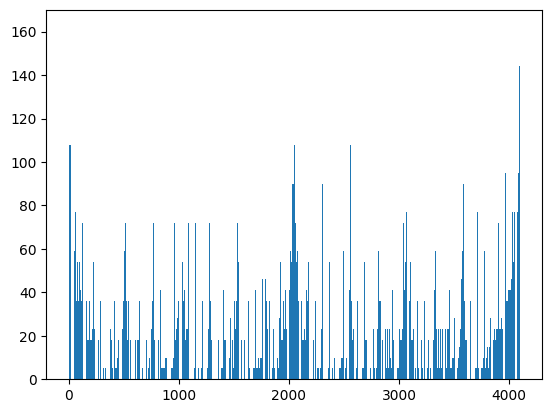

In [22]:
full_spectrum = co_pb.compute_full_spectrum(number_spins, rules_reward)
print(np.where(full_spectrum == np.max(full_spectrum)))
plt.bar(range(2**number_spins), full_spectrum)
plt.show()

In [23]:
from functools import partial

objective = partial(co_pb.estimate_cost, rules_rewards=rules_reward)

result = solve_via_mcco(
    objective_function=objective,
    number_samples=800,
    dit_string_length=number_spins,
    interaction_size=4,
    iteration_number=5,
    threshold_parameter="Auto",
    optimizer=get_optimizer("spin_chain_nn_max"),
)

print("spectrum_pos:", result["spectrum_pos"])
print("spectrum_val:", result["spectrum_val"])
print("spectrum_bin:", result["spectrum_bin"])
print("solution:\n", result["solution_pos"])

spectrum_pos: (1, 7, 10, 17, 21, 36, 39, 43, 51, 55, 57, 64, 66, 124, 130, 160, 223, 250, 251, 252, 258, 259, 496, 504, 514, 516, 517, 527, 575, 576, 894, 960, 991, 1009, 1018, 1026, 1032, 1033, 1035, 1056, 1088, 1280, 1282, 1536, 1551, 1599, 1662, 1855, 1919, 1920, 1922, 1999, 2018, 2021, 2022, 2025, 2027, 2028, 2032, 2035, 2038, 2051, 2057, 2060, 2064, 2069, 2076, 2172, 2174, 2239, 2300, 2367, 2433, 2528, 2560, 2686, 2813, 2879, 2942, 3007, 3008, 3009, 3040, 3055, 3056, 3058, 3065, 3074, 3081, 3104, 3200, 3263, 3324, 3326, 3326, 3328, 3329, 3330, 3391, 3392, 3578, 3580, 3581, 3584, 3586, 3843, 3847, 4029, 4032, 4050)
spectrum_val: (144, 108, 90, 72, 72, 54, 54, 54, 54, 59, 54, 90, 54, 72, 54, 54, 59, 59, 59, 72, 54, 54, 54, 54, 72, 54, 54, 54, 54, 54, 59, 72, 59, 54, 77, 90, 54, 54, 54, 54, 54, 90, 54, 108, 54, 54, 54, 54, 77, 90, 54, 54, 54, 54, 54, 59, 59, 59, 90, 72, 77, 108, 72, 72, 72, 54, 54, 54, 72, 54, 54, 54, 54, 54, 108, 54, 59, 54, 59, 59, 72, 54, 72, 59, 72, 54, 72, 90, 5